# CSoT'26 - ML in Astronomy - Week 3 . Part 1: A CNN and the Training Loop (Starter)

**Goal:** Replace the Week-2 MLP with a **Convolutional Neural Network**, then write the **training loop** that teaches it. By the end you'll watch the training loss fall over several epochs.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). This week it actually matters for speed.
2. Read [`01-convolutions-and-pooling.md`](../01-convolutions-and-pooling.md), [`02-building-a-cnn.md`](../02-building-a-cnn.md), and [`03-the-training-loop.md`](../03-the-training-loop.md).

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Re-create the Week 1 data pipeline

Week 3 builds directly on the `DataLoader`s from Week 1. Paste that pipeline below (download is commented out in the Week-1 solution - uncomment it the first time). If you saved `galaxy_data/` to Google Drive in Week 1, re-mount Drive and point `ImageFolder` at it instead of re-downloading.

After this section you should have `train_loader`, `val_loader`, `test_loader`, `train_ds`, and `num_classes`.

In [1]:
import math
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [2]:
# TODO: paste your Week 1 data pipeline here so that the following names are defined:
#   train_ds, val_ds, test_ds, train_loader, val_loader, test_loader, num_classes
#
# The quickest path is to copy the data-prep cells from
# ../../Week-1/notebooks/week1_data_solution.ipynb (Steps 1-8), then add:
#   num_classes = len(train_ds.classes)
#   print("classes:", train_ds.classes, "num_classes:", num_classes)

from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY'] = userdata.get('gal_morph')

RAW_ROOT = Path("galaxy_raw")      # <-- set up download here
IMAGES_DIR = RAW_ROOT / "images_gz2" /"images"  # flat image folder
DATA_ROOT = Path("galaxy_data")    # ImageFolder root (built in Step 3)

RAW_ROOT.mkdir(parents=True, exist_ok=True)

!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images -p {RAW_ROOT}
!unzip -q {RAW_ROOT}/galaxy-zoo-2-images.zip -d {RAW_ROOT}
print("Files extracted")

print("Downloading gz2_hart16.csv")
!wget -P {RAW_ROOT} https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz

print("Extracting labels file")
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

def high_level_label(gz2_class):
  if "E" in gz2_class:
    return "elliptical"
  elif "SB" in gz2_class:
    return "spiral_barred"
  elif "S" in gz2_class:
    return "spiral"
  else:
    return None

def build_imagefolder_layout(images_dir, mapping_csv,labels_csv, out_root, per_class=200, seed=42,
):
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts


PER_CLASS = 200
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))


Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
100% 3.06G/3.06G [00:35<00:00, 92.1MB/s]

Files extracted
--2026-06-21 14:26:27--  https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz
Resolving gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)... 54.231.136.9, 52.217.124.201, 52.217.200.153, ...
Connecting to gz2hart.s3.amazonaws.com (gz2hart.s3.amazonaws.com)|54.231.136.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78513011 (75M) [application/x-gzip]
Saving to: ‘galaxy_raw/gz2_hart16.csv.gz’

gz2_hart16.csv.gz   100%[===================>]  74.88M  43.7MB/s    in 1.7s    

2026-06-21 14:26:29 (43.7 MB/s) - ‘galaxy_raw/gz2_hart16.csv.gz’ saved [78513011/78513011]

Extracting labels file
Symlinked per class: {'elliptical': 200, 'spiral': 200, 'spiral_barred': 200}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [3]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5],
    ),
])

In [4]:
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
total_size = len(dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(train_ds.dataset.classes)

## Step 1 - Define the CNN

Two `Conv -> ReLU -> Pool` blocks (channels `3 -> 16 -> 32`, each conv `kernel_size=3, padding=1`), then a `Flatten -> Linear -> ReLU -> Linear` head. With a 64x64 input and two 2x2 pools, the feature maps are `(B, 32, 16, 16)`, so the flattened size is `32*16*16 = 8192`. The final layer returns **raw logits** (no softmax). Don't forget `super().__init__()`.

In [5]:
# TODO: define GalaxyCNN(nn.Module).
#   features = nn.Sequential(
#       nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
#       nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
#   classifier = nn.Sequential(
#       nn.Flatten(), nn.Linear(32*16*16, 128), nn.ReLU(), nn.Linear(128, num_classes))
#   forward(x): x = features(x); x = classifier(x); return x

class GalaxyCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2))
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(32*16*16, 128),
        nn.ReLU(),
        nn.Linear(128, num_classes))

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

## Step 2 - Instantiate and move to the device

Use the real `num_classes` from your data, and `.to(device)` so the model lives where the batches will.

In [6]:
# TODO: model = GalaxyCNN(num_classes=num_classes).to(device)
#       print(model)

model = GalaxyCNN(num_classes=num_classes).to(device)
print(model)

GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


## Step 3 - Forward-pass one real batch and count parameters

Pull a batch from `train_loader`, move it to the device, and confirm the output is `(batch_size, num_classes)`. Then print the parameter count - notice the convolutions are tiny and the first `Linear` dominates (compare with the Week-2 MLP's ~1.57M first layer).

In [7]:
# TODO: images, labels = next(iter(train_loader)); move both to device.
#       logits = model(images); print(logits.shape)  # expect (B, num_classes)
#       total = sum(p.numel() for p in model.parameters()); print(f"params: {total:,}")
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)
logits = model(images)
print(logits.shape)
total = sum(p.numel() for p in model.parameters())
print(f"params: {total:,}")

torch.Size([32, 3])
params: 1,054,179


## Step 4 - Loss, optimiser, and a starting-loss sanity check

`CrossEntropyLoss` consumes raw logits + integer labels. `Adam` with `lr=1e-3` is the sensible default. An untrained model on `C` balanced classes should give a loss near `ln(C)`.

In [8]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = optim.Adam(model.parameters(), lr=1e-3)
#       loss = criterion(logits, labels); print(loss.item(), "vs ln(C) =", math.log(num_classes))
criterion = nn.CrossEntropyLoss()
optimiser = optim.Adam(model.parameters(), lr = 1e-3)
loss = criterion(logits, labels)
print(loss.item(), "vs ln(C) = ", math.log(num_classes))

1.099377989768982 vs ln(C) =  1.0986122886681098


## Step 5 - The training loop

For each epoch, loop over `train_loader` and run the **five steps** every batch: `zero_grad -> forward -> loss -> backward -> step`. Accumulate a running loss and store the epoch average in `train_losses`. Call `model.train()` at the start of each epoch and `.to(device)` every batch.

In [9]:
# TODO: write the training loop.
#   num_epochs = 8
#   train_losses = []
#   for epoch in range(num_epochs):
#       model.train(); running = 0.0
#       for inputs, targets in train_loader:
#           inputs, targets = inputs.to(device), targets.to(device)
#           optimizer.zero_grad()
#           outputs = model(inputs)
#           loss = criterion(outputs, targets)
#           loss.backward()
#           optimizer.step()
#           running += loss.item() * inputs.size(0)
#       epoch_loss = running / len(train_loader.dataset)
#       train_losses.append(epoch_loss)
#       print(f"Epoch {epoch+1:2d}/{num_epochs}  train loss: {epoch_loss:.4f}")

epochs = 8
train_losses = []
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for inp, targets in train_loader:
    inp, targets = inp.to(device), targets.to(device)
    optimiser.zero_grad()

    out = model(inp)
    loss = criterion(out, targets)
    loss.backward()
    optimiser.step()
    running_loss += loss.item()*inp.size(0)
  epoch_loss = running_loss / len(train_loader.dataset)
  train_losses.append(epoch_loss)
  print(f"epoch {epoch+1:2d}/{epochs} | train loss: {epoch_loss:.4f}")

epoch  1/8 | train loss: 1.1395
epoch  2/8 | train loss: 1.1005
epoch  3/8 | train loss: 1.0947
epoch  4/8 | train loss: 1.0712
epoch  5/8 | train loss: 1.0680
epoch  6/8 | train loss: 1.0180
epoch  7/8 | train loss: 0.9980
epoch  8/8 | train loss: 0.9669


## Step 6 - Plot the loss curve

A healthy run shows `train_losses` trending **down**. Small wiggles are fine; the trend is what matters.

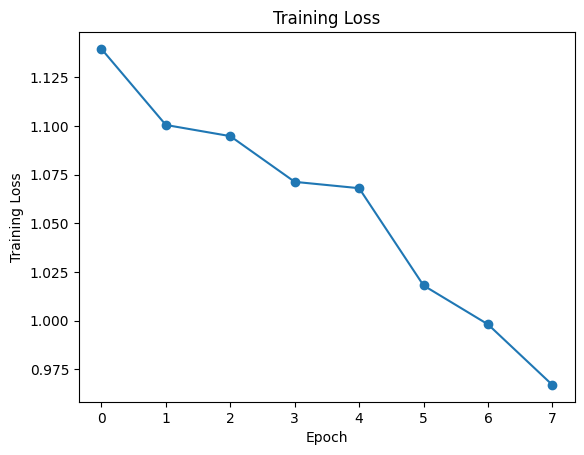

In [10]:
# TODO: plt.plot(train_losses, marker='o'); label axes; title 'Training loss'; plt.show()
plt.plot(train_losses, marker = "o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.show()

## Step 7 (stretch) - Save Part 1's weights for Part 2

Optional but handy: save the trained weights so the Part-2 notebook can load them instead of re-training. Save to Drive so they survive a runtime recycle. (Saving/loading is covered fully in [`07-saving-and-loading-models.md`](../07-saving-and-loading-models.md).)

In [11]:
# TODO (optional): torch.save(model.state_dict(), 'galaxy_model.pth'); print('saved')
from google.colab import drive
drive.mount("/content/drive")
torch.save(model.state_dict(), "/content/drive/MyDrive/galaxy_model.pth")
print("Saved")

Mounted at /content/drive
Saved


## Reflection *(write 2-3 sentences each)*

1. Your CNN's parameter count - where do most of the weights live, and why is that different from the Week-2 MLP?
2. Describe the shape of your training-loss curve. What would it mean if the loss never fell? If it went to `nan`?
3. Low training loss is necessary but not sufficient. What does Part 2 add to check the model is actually good?

*1. params: 1,054,179. first linear layer. unlike MLP's early flattening, CNN's first layer is a convolution that sees image as kernels instead of raw pixel values.*<br>
*2. starts near log(num_classes), and overall trend is decreasing. if didn't fell, perhaps a bad lr or device inconsistencies. nan perhaps due to missing normalisation.*<br>
*3. checking it on val and test data. going beyond accuracy to confusion matrix.*